In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
# NAV History

nav = pd.read_csv("C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\nav_history_clean.csv")

# Fund Master

fund = pd.read_csv("C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\01_fund_master.csv")

# Date

nav["date"] = pd.to_datetime(nav["date"])

# Sort

nav = nav.sort_values(["amfi_code","date"])

# Merge

df = nav.merge(

    fund[["amfi_code","scheme_name"]],

    on="amfi_code",

    how="left"

)

display(df.head())

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [4]:
df["daily_return"] = (

    df.groupby("scheme_name")["nav"]

      .pct_change()

)

df = df.dropna(subset=["daily_return"])

print(df.shape)

display(df.head())

(45960, 5)


,amfi_code,date,nav,scheme_name,daily_return
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210
5,100016,2022-01-10,510.7136,HDFC Top 100 Fund - Regular Plan - Growth,-0.008639


In [5]:
# Annual Risk Free Rate

RF = 0.065

# Daily Risk Free Rate

daily_rf = RF / 252

results = []

for scheme, temp in df.groupby("scheme_name"):

    mean_return = temp["daily_return"].mean()

    # Only Negative Returns

    downside = temp.loc[
        temp["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (
            (mean_return - daily_rf)
            /
            downside_std
        ) * np.sqrt(252)

    results.append({

        "Scheme Name": scheme,

        "Average Daily Return": mean_return,

        "Downside Std Dev": downside_std,

        "Sortino Ratio": sortino

    })

sortino_df = pd.DataFrame(results)

In [6]:
sortino_df = sortino_df.sort_values(

    "Sortino Ratio",

    ascending=False

).reset_index(drop=True)

display(sortino_df)

,Scheme Name,Average Daily Return,Downside Std Dev,Sortino Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.005428,2.385644
1,Kotak Flexicap Fund - Regular - Growth,0.001082,0.005531,2.364320
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.006404,2.146914
3,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.004887,2.140267
4,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.007067,2.029353
5,DSP Midcap Fund - Regular - Growth,0.001055,0.006750,1.875101
6,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.005211,1.850133
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.007133,1.829134
8,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.005145,1.805294
9,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.005238,1.799563


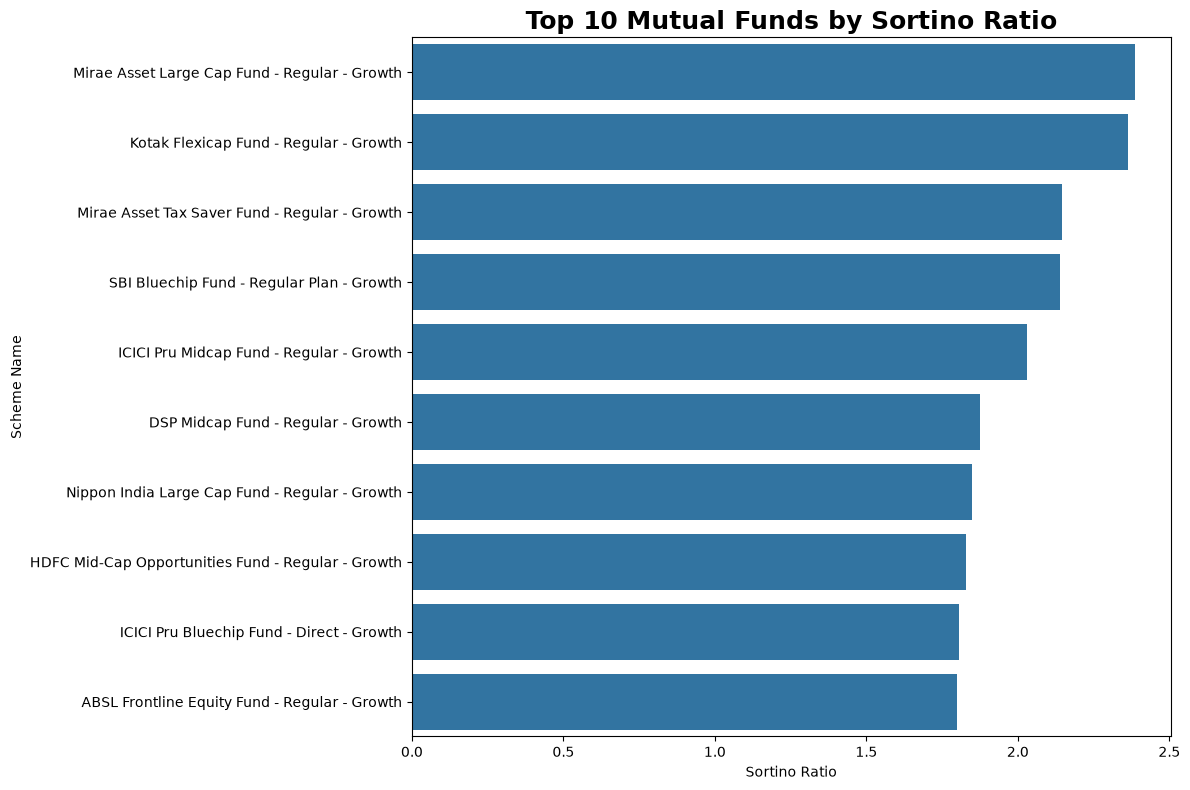

In [7]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=sortino_df.head(10),

    y="Scheme Name",

    x="Sortino Ratio"

)

plt.title(

    "Top 10 Mutual Funds by Sortino Ratio",

    fontsize=18,

    weight="bold"

)

plt.tight_layout()

plt.show()

In [9]:
import os

os.makedirs(

    "data/processed",

    exist_ok=True

)

sortino_df.to_csv(

    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\processed\\sortino_ratio_ranking.csv",

    index=False

)

print("✅ Sortino Ratio Ranking Saved Successfully")

✅ Sortino Ratio Ranking Saved Successfully


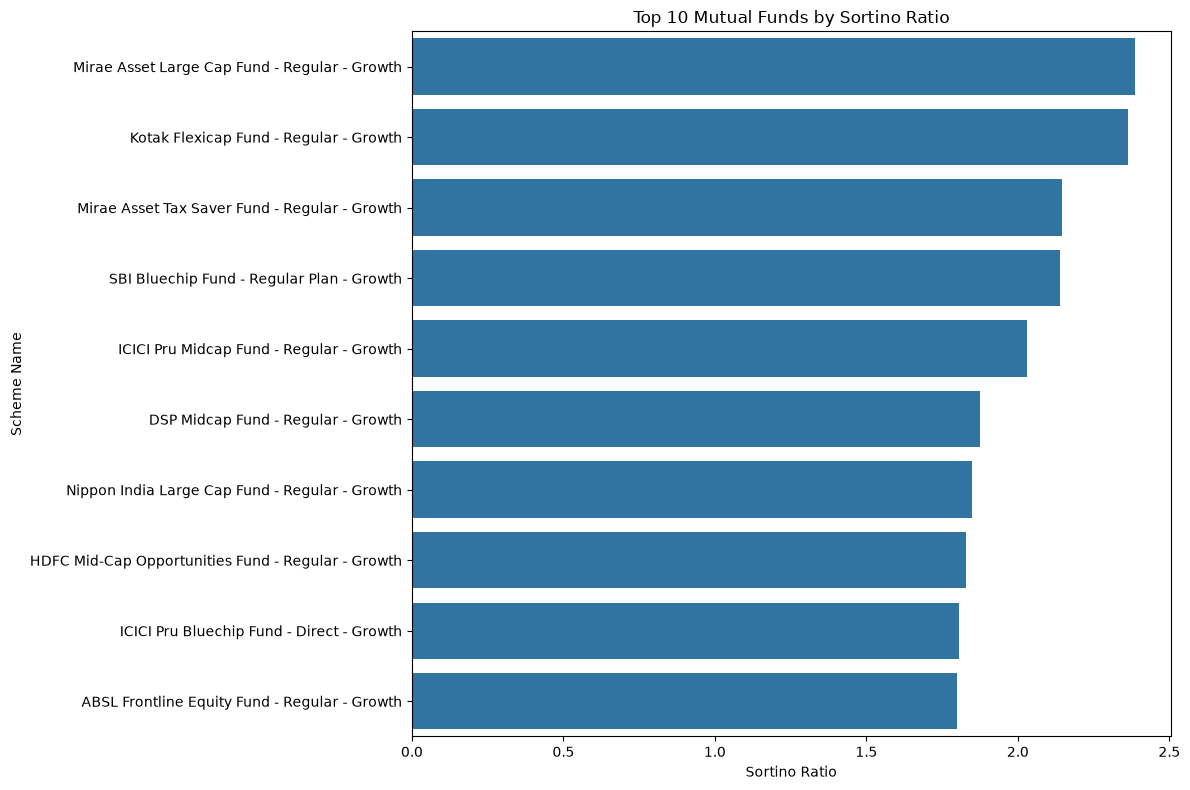

✅ Chart Saved Successfully


In [10]:
os.makedirs(

    "dashboard",

    exist_ok=True

)

plt.figure(figsize=(12,8))

sns.barplot(

    data=sortino_df.head(10),

    y="Scheme Name",

    x="Sortino Ratio"

)

plt.title(

    "Top 10 Mutual Funds by Sortino Ratio"

)

plt.tight_layout()

plt.savefig(

    "dashboard/sortino_ratio_top10.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ Chart Saved Successfully")

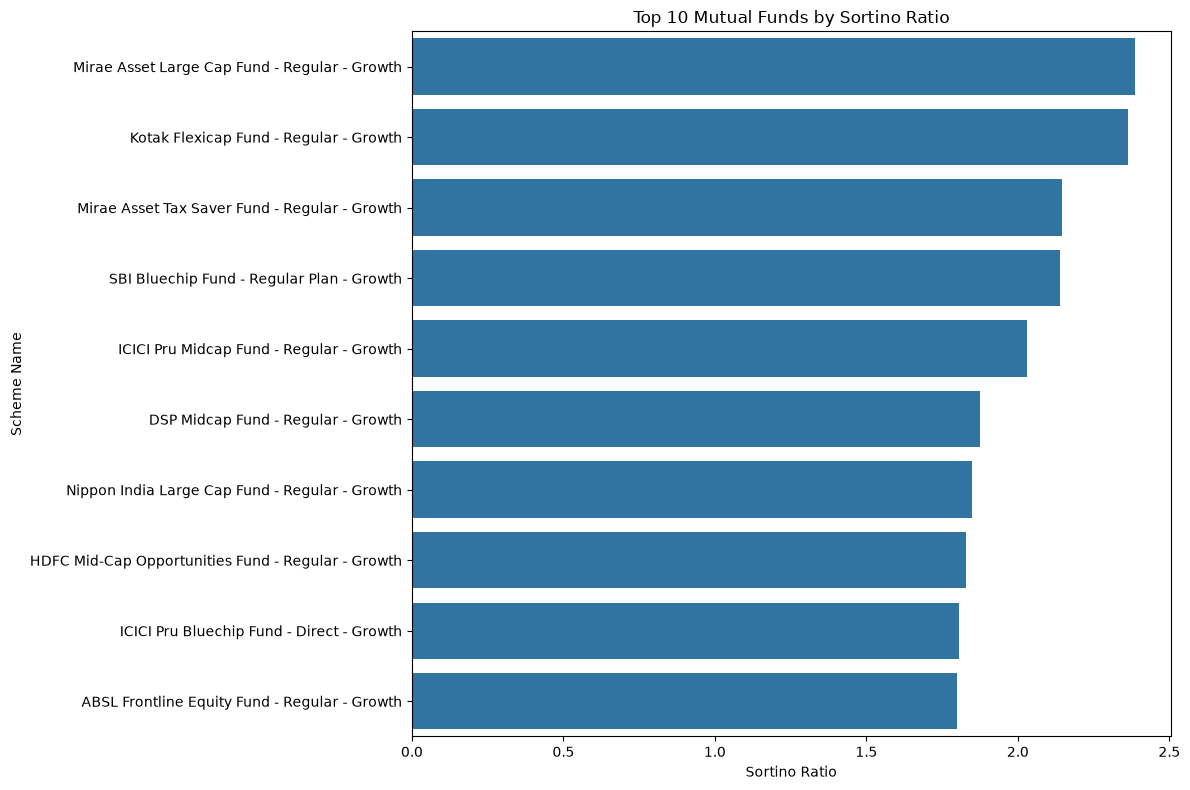

✅ Chart Saved Successfully


In [11]:
os.makedirs(

    "dashboard",

    exist_ok=True

)

plt.figure(figsize=(12,8))

sns.barplot(

    data=sortino_df.head(10),

    y="Scheme Name",

    x="Sortino Ratio"

)

plt.title(

    "Top 10 Mutual Funds by Sortino Ratio"

)

plt.tight_layout()

plt.savefig(

    "dashboard/sortino_ratio_top10.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ Chart Saved Successfully")

## Insight: Sortino Ratio Analysis

The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility. Funds with higher Sortino Ratios generated superior returns while experiencing lower downside risk, making them more attractive for conservative long-term investors.

**Chart Reference:** Top 10 Mutual Funds by Sortino Ratio